# Arabic Sentiment Analysis

A reproducible study of Arabic sentiment classification on the ArSarcasm-v2 dataset.

## Notebook roadmap

1. Setup and configuration
2. Dataset loading and validation
3. Exploratory data analysis and splitting
4. Arabic text preprocessing
5. Feature representations
6. Model development and tuning
7. Preprocessing ablation
8. Data augmentation
9. Class-imbalance handling
10. Comparative evaluation and error analysis

## 1. Setup and configuration

This section loads the shared experiment configuration, fixes sources of randomness, and selects the available compute device.

In [1]:
from __future__ import annotations

import hashlib
import html
import platform
import random
import re
import shutil
import unicodedata
from functools import lru_cache
from pathlib import Path
from urllib.request import urlopen

import emoji
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import qalsadi.lemmatizer
import seaborn as sns
import torch
import yaml
from IPython.display import display
from nltk.corpus import stopwords
from nltk.stem.isri import ISRIStemmer
from sklearn.model_selection import train_test_split

In [2]:
def find_project_root(start: Path) -> Path:
    """Find the repository root from a notebook or project-root kernel."""
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").is_file():
            return candidate
    raise FileNotFoundError("Could not find the repository root.")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
CONFIG_PATH = PROJECT_ROOT / "configs" / "default.yaml"

with CONFIG_PATH.open(encoding="utf-8") as config_file:
    CONFIG = yaml.safe_load(config_file)

PATHS = {
    name: PROJECT_ROOT / relative_path
    for name, relative_path in CONFIG["paths"].items()
}

CONFIG_PATH.relative_to(PROJECT_ROOT)

PosixPath('configs/default.yaml')

In [3]:
SEED = int(CONFIG["project"]["seed"])
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if CONFIG["runtime"]["deterministic"]:
    torch.use_deterministic_algorithms(True, warn_only=True)

device_preference = CONFIG["runtime"]["device"]
if device_preference == "auto":
    device_name = "mps" if torch.backends.mps.is_available() else "cpu"
else:
    device_name = device_preference

DEVICE = torch.device(device_name)

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(context="notebook", style="whitegrid")

In [4]:
pd.DataFrame(
    {
        "value": [
            CONFIG["project"]["name"],
            platform.python_version(),
            torch.__version__,
            str(DEVICE),
            SEED,
        ]
    },
    index=["project", "python", "pytorch", "device", "seed"],
)

,value
project,arabic-sentiment-analysis
python,3.12.4
pytorch,2.14.0
device,mps
seed,42


## 2. Dataset loading and validation

ArSarcasm-v2 contains Arabic tweets annotated for sentiment, sarcasm, and dialect. The dataset authors provide 12,548 training records and 3,000 testing records. Both files are fully labeled.

Sources:

- [Official ArSarcasm-v2 repository](https://github.com/iabufarha/ArSarcasm-v2)
- [WANLP 2021 task overview](https://aclanthology.org/2021.wanlp-1.36/)
- [Dataset license](https://github.com/iabufarha/ArSarcasm-v2/blob/main/LICENSE)

The source revision and SHA-256 digests are pinned below. Raw CSV files are downloaded into the Git-ignored `data/raw/` directory and are never modified in place.

In [5]:
DATASET_REVISION = "eb85513e133cfc67e30aca4968fadbe2594fcb42"
OFFICIAL_RAW_BASE = (
    "https://raw.githubusercontent.com/iabufarha/ArSarcasm-v2/"
    f"{DATASET_REVISION}/ArSarcasm-v2"
)

DATASET_MANIFEST = {
    "training": {
        "filename": "training_data.csv",
        "url": f"{OFFICIAL_RAW_BASE}/training_data.csv",
        "sha256": ("1da727eb763459f436c4e61f52c6a0bc63d5300af8fcc99b5675ae4616dae04a"),
        "rows": 12_548,
    },
    "testing": {
        "filename": "testing_data.csv",
        "url": f"{OFFICIAL_RAW_BASE}/testing_data.csv",
        "sha256": ("0f0a77ba8a4a0a9370846a42a93a63244092f1fb30a909595b70e17e299bcf6c"),
        "rows": 3_000,
    },
}

DATASET_MANIFEST

{'training': {'filename': 'training_data.csv',
  'url': 'https://raw.githubusercontent.com/iabufarha/ArSarcasm-v2/eb85513e133cfc67e30aca4968fadbe2594fcb42/ArSarcasm-v2/training_data.csv',
  'sha256': '1da727eb763459f436c4e61f52c6a0bc63d5300af8fcc99b5675ae4616dae04a',
  'rows': 12548},
 'testing': {'filename': 'testing_data.csv',
  'url': 'https://raw.githubusercontent.com/iabufarha/ArSarcasm-v2/eb85513e133cfc67e30aca4968fadbe2594fcb42/ArSarcasm-v2/testing_data.csv',
  'sha256': '0f0a77ba8a4a0a9370846a42a93a63244092f1fb30a909595b70e17e299bcf6c',
  'rows': 3000}}

In [6]:
def file_sha256(path: Path) -> str:
    """Calculate a file's SHA-256 digest without loading it into memory."""
    digest = hashlib.sha256()
    with path.open("rb") as source:
        for chunk in iter(lambda: source.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def download_verified_file(specification: dict[str, object]) -> Path:
    """Download one immutable dataset file and verify its checksum."""
    raw_directory = PATHS["raw_data"]
    raw_directory.mkdir(parents=True, exist_ok=True)

    destination = raw_directory / str(specification["filename"])
    expected_digest = str(specification["sha256"])

    if destination.exists():
        observed_digest = file_sha256(destination)
        if observed_digest != expected_digest:
            raise ValueError(f"Checksum mismatch for existing file: {destination.name}")
        return destination

    temporary_path = destination.with_suffix(".download")
    temporary_path.unlink(missing_ok=True)

    try:
        with (
            urlopen(str(specification["url"]), timeout=60) as response,
            temporary_path.open("wb") as target,
        ):
            shutil.copyfileobj(response, target)

        observed_digest = file_sha256(temporary_path)
        if observed_digest != expected_digest:
            raise ValueError(f"Checksum mismatch after downloading {destination.name}")
        temporary_path.replace(destination)
    finally:
        temporary_path.unlink(missing_ok=True)

    return destination


DATASET_PATHS = {
    split_name: download_verified_file(specification)
    for split_name, specification in DATASET_MANIFEST.items()
}

{name: path.relative_to(PROJECT_ROOT) for name, path in DATASET_PATHS.items()}

{'training': PosixPath('data/raw/training_data.csv'),
 'testing': PosixPath('data/raw/testing_data.csv')}

In [7]:
EXPECTED_DIALECTS = {"egypt", "gulf", "levant", "magreb", "msa"}


def validate_dataset(
    frame: pd.DataFrame,
    split_name: str,
    expected_rows: int,
) -> None:
    """Reject incomplete or structurally unexpected source data."""
    expected_columns = list(CONFIG["data"]["expected_columns"])
    expected_sentiments = set(CONFIG["data"]["classes"])

    problems = []
    if len(frame) != expected_rows:
        problems.append(f"expected {expected_rows} rows, found {len(frame)}")
    if list(frame.columns) != expected_columns:
        problems.append("unexpected columns or column order")
    if frame.isna().any().any():
        problems.append("missing values found")
    if set(frame["sentiment"].unique()) != expected_sentiments:
        problems.append("unexpected sentiment labels")
    if set(frame["dialect"].unique()) != EXPECTED_DIALECTS:
        problems.append("unexpected dialect labels")
    if not pd.api.types.is_bool_dtype(frame["sarcasm"]):
        problems.append("sarcasm must be boolean")

    normalized_text = (
        frame["tweet"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
    )
    if normalized_text.eq("").any():
        problems.append("blank tweet text found")

    if problems:
        raise ValueError(f"{split_name}: {'; '.join(problems)}")


DATASET_FRAMES = {}
for split_name, specification in DATASET_MANIFEST.items():
    frame = pd.read_csv(DATASET_PATHS[split_name])
    validate_dataset(frame, split_name, int(specification["rows"]))
    DATASET_FRAMES[split_name] = frame

raw_data = pd.concat(
    [
        frame.assign(source_split=split_name, source_row=np.arange(len(frame)))
        for split_name, frame in DATASET_FRAMES.items()
    ],
    ignore_index=True,
)

raw_data.shape

(15548, 6)

In [8]:
source_summary = pd.DataFrame(
    [
        {
            "source_split": split_name,
            "rows": len(DATASET_FRAMES[split_name]),
            "columns": len(DATASET_FRAMES[split_name].columns),
            "missing_values": int(DATASET_FRAMES[split_name].isna().sum().sum()),
            "sha256": file_sha256(DATASET_PATHS[split_name]),
        }
        for split_name in DATASET_MANIFEST
    ]
)

sentiment_distribution = pd.crosstab(
    raw_data["sentiment"],
    raw_data["source_split"],
    margins=True,
).rename_axis(index="sentiment", columns="source")

display(source_summary)
display(sentiment_distribution)

,source_split,rows,columns,missing_values,sha256
0,training,12548,4,0,1da727eb763459f436c4e61f52c6a0bc63d5300af8fcc9...
1,testing,3000,4,0,0f0a77ba8a4a0a9370846a42a93a63244092f1fb30a909...


source,testing,training,All
sentiment,,,
NEG,1677,4621,6298
NEU,748,5747,6495
POS,575,2180,2755
All,3000,12548,15548


In [9]:
audit_text = (
    raw_data["tweet"].astype(str).str.strip().str.replace(r"\s+", " ", regex=True)
)
duplicate_mask = audit_text.duplicated(keep=False)

duplicate_groups = (
    raw_data.assign(_audit_text=audit_text)
    .groupby("_audit_text", sort=False)
    .agg(
        rows=("tweet", "size"),
        source_splits=("source_split", "nunique"),
        sentiment_labels=("sentiment", "nunique"),
        sarcasm_labels=("sarcasm", "nunique"),
        dialect_labels=("dialect", "nunique"),
    )
)
duplicate_groups = duplicate_groups[duplicate_groups["rows"] > 1]

duplicate_audit = pd.Series(
    {
        "combined_rows": len(raw_data),
        "exact_duplicate_rows": int(
            raw_data.duplicated(
                subset=["tweet", "sarcasm", "sentiment", "dialect"]
            ).sum()
        ),
        "rows_in_duplicate_text_groups": int(duplicate_mask.sum()),
        "duplicate_text_groups": len(duplicate_groups),
        "groups_crossing_source_splits": int(
            duplicate_groups["source_splits"].gt(1).sum()
        ),
        "groups_with_sentiment_conflicts": int(
            duplicate_groups["sentiment_labels"].gt(1).sum()
        ),
        "groups_with_sarcasm_conflicts": int(
            duplicate_groups["sarcasm_labels"].gt(1).sum()
        ),
        "groups_with_dialect_conflicts": int(
            duplicate_groups["dialect_labels"].gt(1).sum()
        ),
    },
    name="count",
).to_frame()

duplicate_audit

,count
combined_rows,15548
exact_duplicate_rows,18
rows_in_duplicate_text_groups,132
duplicate_text_groups,65
groups_crossing_source_splits,2
groups_with_sentiment_conflicts,26
groups_with_sarcasm_conflicts,20
groups_with_dialect_conflicts,21


### Validation notes

The notebook deliberately reports duplicate counts without displaying tweet contents. Duplicate normalized texts will be treated as groups during the new 60/20/20 split so equivalent text cannot leak across partitions. Conflicting duplicate annotations will be resolved by an explicit rule in the splitting section rather than silently overwritten here.

## 3. Dataset preparation and splitting

The assignment requires a new 60/20/20 split. Before splitting, whitespace-equivalent tweet text is grouped to prevent identical content from leaking across partitions. Groups containing contradictory sentiment targets are removed in full. Remaining duplicate groups are collapsed to one representative; deterministic modes resolve auxiliary sarcasm and dialect disagreements.

In [10]:
def deterministic_mode(values: pd.Series) -> object:
    """Return a stable mode, breaking count ties lexicographically."""
    counts = values.value_counts(dropna=False)
    winners = counts[counts.eq(counts.max())].index.tolist()
    return sorted(winners, key=str)[0]


data_with_split_key = raw_data.assign(_split_text=audit_text)
target_label_counts = data_with_split_key.groupby("_split_text")[
    CONFIG["data"]["target"]
].nunique()
conflicting_target_keys = set(target_label_counts[target_label_counts.gt(1)].index)
target_conflict_mask = data_with_split_key["_split_text"].isin(conflicting_target_keys)
eligible_data = data_with_split_key.loc[~target_conflict_mask].copy()

clean_data = (
    eligible_data.groupby("_split_text", sort=False, as_index=False)
    .agg(
        tweet=("tweet", "first"),
        sentiment=("sentiment", "first"),
        sarcasm=("sarcasm", deterministic_mode),
        dialect=("dialect", deterministic_mode),
        source_split=("source_split", "first"),
        source_row=("source_row", "first"),
        duplicate_count=("tweet", "size"),
    )
    .rename(columns={"_split_text": "split_text_key"})
)
clean_data["record_id"] = clean_data["split_text_key"].map(
    lambda text: hashlib.sha256(text.encode("utf-8")).hexdigest()[:16]
)
clean_data = clean_data.sort_values("record_id").reset_index(drop=True)

if clean_data["record_id"].duplicated().any():
    raise ValueError("Record ID collision detected.")

cleaning_summary = pd.Series(
    {
        "original_rows": len(raw_data),
        "target_conflict_groups_dropped": len(conflicting_target_keys),
        "rows_in_target_conflict_groups": int(target_conflict_mask.sum()),
        "redundant_duplicate_rows_collapsed": len(eligible_data) - len(clean_data),
        "clean_rows_retained": len(clean_data),
        "total_rows_removed": len(raw_data) - len(clean_data),
    },
    name="count",
).to_frame()

cleaning_summary

,count
original_rows,15548
target_conflict_groups_dropped,26
rows_in_target_conflict_groups,52
redundant_duplicate_rows_collapsed,41
clean_rows_retained,15455
total_rows_removed,93


In [11]:
train_size = float(CONFIG["split"]["train_size"])
validation_size = float(CONFIG["split"]["validation_size"])
test_size = float(CONFIG["split"]["test_size"])

if not np.isclose(train_size + validation_size + test_size, 1.0):
    raise ValueError("Configured split proportions must sum to one.")

stratification_target = CONFIG["split"]["stratify_by"]
remainder_size = validation_size + test_size

train_data, remainder_data = train_test_split(
    clean_data,
    test_size=remainder_size,
    random_state=SEED,
    shuffle=True,
    stratify=clean_data[stratification_target],
)
validation_data, test_data = train_test_split(
    remainder_data,
    test_size=test_size / remainder_size,
    random_state=SEED,
    shuffle=True,
    stratify=remainder_data[stratification_target],
)

PARTITIONS = {
    "train": train_data.sort_values("record_id").reset_index(drop=True),
    "validation": validation_data.sort_values("record_id").reset_index(drop=True),
    "test": test_data.sort_values("record_id").reset_index(drop=True),
}

split_data = pd.concat(
    [frame.assign(partition=name) for name, frame in PARTITIONS.items()],
    ignore_index=True,
)

In [12]:
partition_ids = {name: set(frame["record_id"]) for name, frame in PARTITIONS.items()}
partition_names = list(partition_ids)
for left_index, left_name in enumerate(partition_names):
    for right_name in partition_names[left_index + 1 :]:
        overlap = partition_ids[left_name] & partition_ids[right_name]
        if overlap:
            raise ValueError(f"Record leakage between {left_name} and {right_name}.")

if len(split_data) != len(clean_data):
    raise ValueError("Split row counts do not match the clean dataset.")
if split_data["record_id"].duplicated().any():
    raise ValueError("Duplicate record IDs remain after splitting.")

split_counts = split_data["partition"].value_counts().reindex(PARTITIONS)
split_proportions = (split_counts / len(split_data)).rename("proportion")
split_summary = pd.concat([split_counts.rename("rows"), split_proportions], axis=1)

sentiment_counts = pd.crosstab(
    split_data["partition"],
    split_data["sentiment"],
).reindex(index=PARTITIONS, columns=CONFIG["data"]["classes"])
sentiment_proportions = sentiment_counts.div(sentiment_counts.sum(axis=1), axis=0)

processed_directory = PATHS["processed_data"]
processed_directory.mkdir(parents=True, exist_ok=True)
split_manifest_path = processed_directory / "split_manifest.csv"
split_data[
    [
        "record_id",
        "partition",
        "sentiment",
        "sarcasm",
        "dialect",
        "source_split",
        "source_row",
        "duplicate_count",
    ]
].to_csv(split_manifest_path, index=False)

split_summary_display = split_summary.copy()
split_summary_display["proportion"] = split_summary_display["proportion"].map(
    "{:.2%}".format
)
sentiment_proportions_display = sentiment_proportions.map("{:.2%}".format)

display(split_summary_display)
display(sentiment_counts)
display(sentiment_proportions_display)
print(f"Saved local manifest: {split_manifest_path.relative_to(PROJECT_ROOT)}")

,rows,proportion
partition,,
train,9273,60.00%
validation,3091,20.00%
test,3091,20.00%


sentiment,NEG,NEU,POS
partition,,,
train,3749,3877,1647
validation,1249,1292,550
test,1250,1292,549


sentiment,NEG,NEU,POS
partition,,,
train,40.43%,41.81%,17.76%
validation,40.41%,41.80%,17.79%
test,40.44%,41.80%,17.76%


Saved local manifest: data/processed/split_manifest.csv


### Split policy

All future fitting operations use `PARTITIONS["train"]`. Validation data is reserved for model and hyperparameter selection. The test partition remains untouched until configurations are frozen. Exploratory analysis in the next subsection uses training data, while cross-partition summaries are limited to verifying that stratification behaved as intended. The generated split manifest is local and reproducible; it is excluded from Git with the processed data.

### 3.1 Training-only exploratory analysis

The following analysis uses only the training partition. It characterizes the target imbalance, auxiliary labels, and surface-level text lengths without inspecting validation or test text.

In [13]:
def distribution_table(values: pd.Series, order: list[object]) -> pd.DataFrame:
    """Return ordered counts and proportions for a categorical series."""
    counts = values.value_counts().reindex(order, fill_value=0)
    return pd.DataFrame(
        {
            "count": counts,
            "proportion": counts / counts.sum(),
        }
    )


training_eda = PARTITIONS["train"].copy()
training_eda["character_count"] = training_eda["tweet"].str.len()
training_eda["token_count"] = training_eda["tweet"].str.split().str.len()
training_eda["sarcasm_label"] = training_eda["sarcasm"].map(
    {False: "Non-sarcastic", True: "Sarcastic"}
)

sentiment_order = list(CONFIG["data"]["classes"])
sarcasm_order = ["Non-sarcastic", "Sarcastic"]
dialect_order = (
    training_eda["dialect"].value_counts().sort_values(ascending=False).index.tolist()
)

sentiment_table = distribution_table(training_eda["sentiment"], sentiment_order)
sarcasm_table = distribution_table(training_eda["sarcasm_label"], sarcasm_order)
dialect_table = distribution_table(training_eda["dialect"], dialect_order)

for title, table in (
    ("Sentiment distribution", sentiment_table),
    ("Sarcasm distribution", sarcasm_table),
    ("Dialect distribution", dialect_table),
):
    print(title)
    display(table.assign(proportion=table["proportion"].map("{:.2%}".format)))

Sentiment distribution


,count,proportion
sentiment,,
NEG,3749,40.43%
NEU,3877,41.81%
POS,1647,17.76%


Sarcasm distribution


,count,proportion
sarcasm_label,,
Non-sarcastic,7496,80.84%
Sarcastic,1777,19.16%


Dialect distribution


,count,proportion
dialect,,
msa,6520,70.31%
egypt,1762,19.00%
gulf,567,6.11%
levant,396,4.27%
magreb,28,0.30%


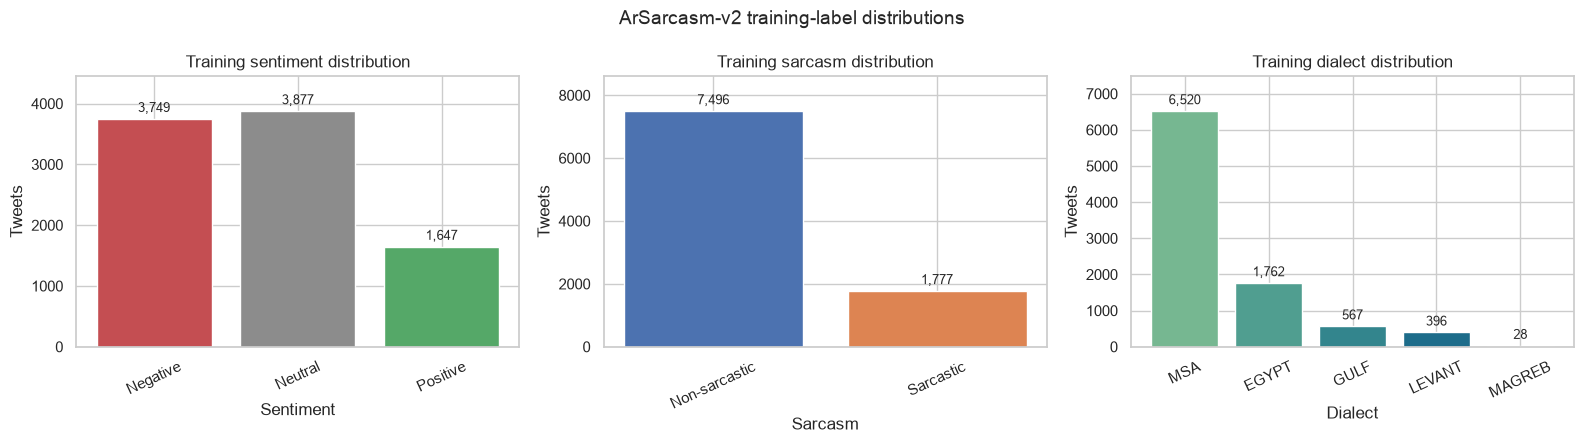

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(16, 4.5))

distribution_specs = [
    (
        sentiment_table,
        ["Negative", "Neutral", "Positive"],
        ["#c44e52", "#8c8c8c", "#55a868"],
        "Sentiment",
    ),
    (
        sarcasm_table,
        sarcasm_order,
        ["#4c72b0", "#dd8452"],
        "Sarcasm",
    ),
    (
        dialect_table,
        [label.upper() for label in dialect_order],
        sns.color_palette("crest", len(dialect_order)),
        "Dialect",
    ),
]

for axis, (table, labels, colors, title) in zip(axes, distribution_specs, strict=True):
    bars = axis.bar(labels, table["count"], color=colors)
    axis.bar_label(bars, fmt="{:,.0f}", padding=3, fontsize=9)
    axis.set_title(f"Training {title.lower()} distribution")
    axis.set_xlabel(title)
    axis.set_ylabel("Tweets")
    axis.tick_params(axis="x", rotation=25)
    axis.margins(y=0.15)

figure.suptitle("ArSarcasm-v2 training-label distributions", fontsize=14)
figure.tight_layout()
plt.show()

character_count             token_count           
                     mean median  max        mean median max
sentiment                                                   
NEG                109.02  111.0  295       17.80   18.0  57
NEU                102.72  108.0  302       13.87   13.0  54
POS                 88.44   88.0  302       13.57   13.0  52

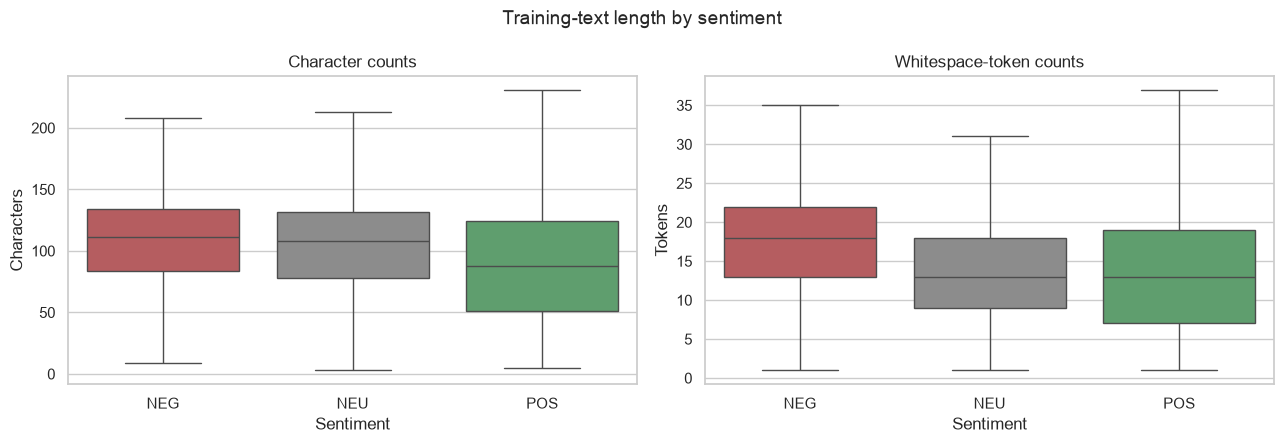

In [15]:
length_summary = (
    training_eda.groupby("sentiment", observed=True)[["character_count", "token_count"]]
    .agg(["mean", "median", "max"])
    .reindex(sentiment_order)
    .round(2)
)
display(length_summary)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sentiment_colors = {
    "NEG": "#c44e52",
    "NEU": "#8c8c8c",
    "POS": "#55a868",
}

sns.boxplot(
    data=training_eda,
    x="sentiment",
    y="character_count",
    order=sentiment_order,
    hue="sentiment",
    palette=sentiment_colors,
    legend=False,
    showfliers=False,
    ax=axes[0],
)
sns.boxplot(
    data=training_eda,
    x="sentiment",
    y="token_count",
    order=sentiment_order,
    hue="sentiment",
    palette=sentiment_colors,
    legend=False,
    showfliers=False,
    ax=axes[1],
)
axes[0].set(title="Character counts", xlabel="Sentiment", ylabel="Characters")
axes[1].set(title="Whitespace-token counts", xlabel="Sentiment", ylabel="Tokens")
figure.suptitle("Training-text length by sentiment", fontsize=14)
figure.tight_layout()
plt.show()

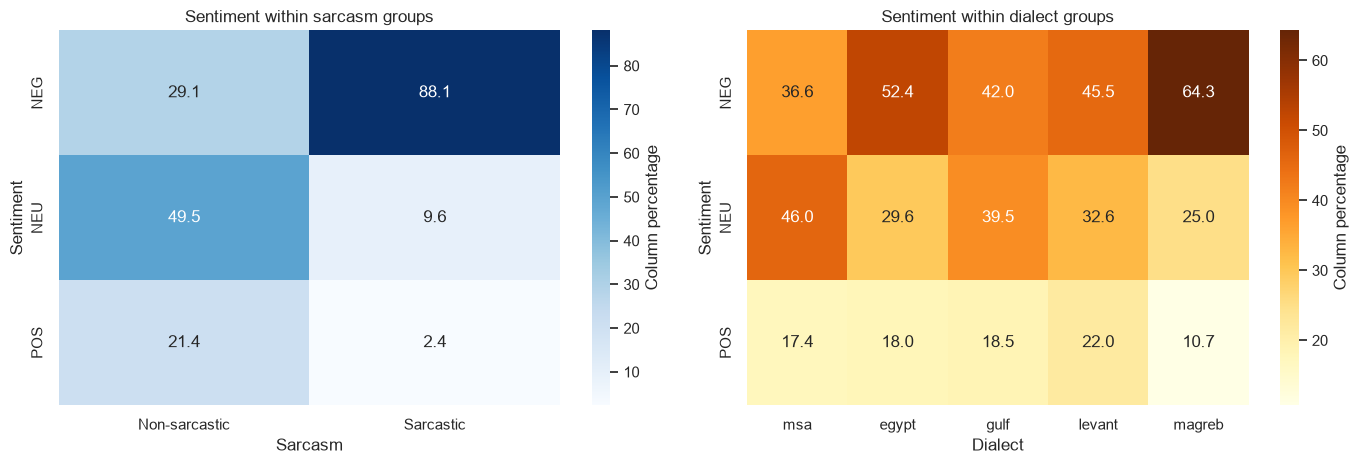

In [16]:
sentiment_by_sarcasm = (
    pd.crosstab(
        training_eda["sentiment"],
        training_eda["sarcasm_label"],
        normalize="columns",
    )
    .reindex(index=sentiment_order, columns=sarcasm_order)
    .mul(100)
)
sentiment_by_dialect = (
    pd.crosstab(
        training_eda["sentiment"],
        training_eda["dialect"],
        normalize="columns",
    )
    .reindex(index=sentiment_order, columns=dialect_order)
    .mul(100)
)

figure, axes = plt.subplots(1, 2, figsize=(14, 4.8))
sns.heatmap(
    sentiment_by_sarcasm,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    cbar_kws={"label": "Column percentage"},
    ax=axes[0],
)
sns.heatmap(
    sentiment_by_dialect,
    annot=True,
    fmt=".1f",
    cmap="YlOrBr",
    cbar_kws={"label": "Column percentage"},
    ax=axes[1],
)
axes[0].set(title="Sentiment within sarcasm groups", xlabel="Sarcasm")
axes[1].set(title="Sentiment within dialect groups", xlabel="Dialect")
for axis in axes:
    axis.set_ylabel("Sentiment")
figure.tight_layout()
plt.show()

### Exploratory findings

- Positive sentiment is the minority target class at 17.76% of training data, compared with 40.43% negative and 41.81% neutral. This supports macro F1 as the primary selection metric and motivates the later augmentation and class-weighting experiments.
- Sarcastic tweets form 19.16% of training data. Approximately 88% of sarcastic training tweets are negative, confirming a strong relationship between sarcasm and negative sentiment.
- MSA accounts for about 70% of training data, while Maghrebi has only 28 examples. Dialect-specific results must therefore be interpreted cautiously.
- The length summaries show whether any sentiment class is associated with systematically longer text; length itself will not be used as a target-derived preprocessing rule.

## 4. Arabic text preprocessing

Arabic social-media text contains orthographic variation, elongation, diacritics, URLs, mentions, hashtags, and emojis. The pipeline below exposes each operation as a configuration switch so the later ablation study can remove one component at a time. Negation terms are explicitly protected because removing or morphologically reducing them can invert sentiment.

In [17]:
NLTK_DATA_DIRECTORY = PATHS["artifacts"] / "nltk_data"
NLTK_DATA_DIRECTORY.mkdir(parents=True, exist_ok=True)
nltk_data_path = str(NLTK_DATA_DIRECTORY)
if nltk_data_path not in nltk.data.path:
    nltk.data.path.insert(0, nltk_data_path)

try:
    nltk.data.find("corpora/stopwords")
except LookupError:
    downloaded = nltk.download(
        "stopwords",
        download_dir=NLTK_DATA_DIRECTORY,
        quiet=True,
        raise_on_error=True,
    )
    if not downloaded:
        raise RuntimeError("Could not download the NLTK stop-word corpus.") from None

NEGATION_TERMS = {
    "لا",
    "ليس",
    "ليست",
    "لست",
    "لن",
    "لم",
    "ما",
    "مش",
    "مو",
    "مفيش",
    "بدون",
    "غير",
}
ALL_ARABIC_STOPWORDS = set(stopwords.words("arabic"))
ARABIC_STOPWORDS = ALL_ARABIC_STOPWORDS - NEGATION_TERMS
stopword_digest = hashlib.sha256(
    "\n".join(sorted(ARABIC_STOPWORDS)).encode("utf-8")
).hexdigest()

pd.Series(
    {
        "stopword_count": len(ARABIC_STOPWORDS),
        "protected_negations": len(NEGATION_TERMS),
        "stopword_sha256": stopword_digest,
    },
    name="value",
).to_frame()

,value
stopword_count,693
protected_negations,12
stopword_sha256,c9b74cded5222de75ca75f704c2ecffe7827246d139931...


In [18]:
URL_PATTERN = re.compile(r"(?:https?://|www\.)\S+", flags=re.IGNORECASE)
HTML_TAG_PATTERN = re.compile(r"<[^>]+>")
MENTION_PATTERN = re.compile(r"(?<!\w)@[\w_]+")
HASHTAG_PATTERN = re.compile(r"#([\w_]+)")
EMOJI_ALIAS_PATTERN = re.compile(r":([a-zA-Z0-9_+&-]+):")
ARABIC_DIACRITICS_PATTERN = re.compile(
    r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]"
)
TATWEEL_PATTERN = re.compile(r"\u0640")
DIGIT_PATTERN = re.compile(r"\d+")
REPEATED_CHARACTER_PATTERN = re.compile(r"(\S)\1{2,}")
WHITESPACE_PATTERN = re.compile(r"\s+")
ARABIC_TOKEN_PATTERN = re.compile(r"[\u0600-\u06FF]+")

ARABIC_CHARACTER_TRANSLATION = str.maketrans(
    {
        "أ": "ا",
        "إ": "ا",
        "آ": "ا",
        "ٱ": "ا",
        "ى": "ي",
    }
)
NORMALIZED_ARABIC_STOPWORDS = {
    word.translate(ARABIC_CHARACTER_TRANSLATION) for word in ARABIC_STOPWORDS
}
NORMALIZED_ALL_ARABIC_STOPWORDS = {
    word.translate(ARABIC_CHARACTER_TRANSLATION) for word in ALL_ARABIC_STOPWORDS
}
ALWAYS_PROTECTED_TOKENS = {"مستخدم", "رقم"}
QALSADI_LEMMATIZER = qalsadi.lemmatizer.Lemmatizer()
ISRI_STEMMER = ISRIStemmer()

In [19]:
def replace_emoji_alias(match: re.Match[str]) -> str:
    """Turn a demojized alias into one stable token."""
    alias = match.group(1).replace("-", "_")
    return f" emoji_{alias} "


def remove_unicode_punctuation_and_symbols(text: str) -> str:
    """Replace Unicode punctuation and symbols with spaces."""
    return "".join(
        character
        if character == "_" or unicodedata.category(character)[0] not in {"P", "S"}
        else " "
        for character in text
    )


@lru_cache(maxsize=50_000)
def lemmatize_arabic_token(token: str) -> str:
    """Return a cached Qalsadi lemma, falling back to the input token."""
    lemma = QALSADI_LEMMATIZER.lemmatize(token)
    return lemma if isinstance(lemma, str) and lemma else token


def preprocess_arabic(
    text: str,
    overrides: dict[str, bool] | None = None,
) -> str:
    """Apply the configurable Arabic social-media preprocessing pipeline."""
    if not isinstance(text, str):
        raise TypeError("preprocess_arabic expects a string.")

    options = dict(CONFIG["preprocessing"])
    if overrides:
        unknown_options = set(overrides) - set(options)
        if unknown_options:
            raise KeyError(f"Unknown preprocessing options: {unknown_options}")
        options.update(overrides)
    if options["lemmatize_arabic_tokens"] and options["stem_arabic_tokens"]:
        raise ValueError("Lemmatization and stemming cannot both be enabled.")

    processed = text
    if options["decode_html_entities"]:
        processed = html.unescape(processed)
    if options["remove_html_tags"]:
        processed = HTML_TAG_PATTERN.sub(" ", processed)
    if options["remove_urls"]:
        processed = URL_PATTERN.sub(" ", processed)
    if options["replace_mentions"]:
        processed = MENTION_PATTERN.sub(" مستخدم ", processed)
    if options["demojize_emojis"]:
        processed = emoji.demojize(processed)
        processed = EMOJI_ALIAS_PATTERN.sub(replace_emoji_alias, processed)
    if options["unpack_hashtags"]:
        processed = HASHTAG_PATTERN.sub(
            lambda match: f" {match.group(1).replace('_', ' ')} ",
            processed,
        )
    if options["remove_diacritics"]:
        processed = ARABIC_DIACRITICS_PATTERN.sub("", processed)
    if options["remove_tatweel"]:
        processed = TATWEEL_PATTERN.sub("", processed)
    if options["normalize_digits"]:
        processed = DIGIT_PATTERN.sub(" رقم ", processed)
    if options["remove_punctuation_symbols"]:
        processed = remove_unicode_punctuation_and_symbols(processed)
    if options["collapse_repeated_characters"]:
        processed = REPEATED_CHARACTER_PATTERN.sub(r"\1\1", processed)

    tokens = WHITESPACE_PATTERN.sub(" ", processed).strip().split()
    if options["preserve_negation"]:
        raw_stopwords = ARABIC_STOPWORDS
        normalized_stopwords = NORMALIZED_ARABIC_STOPWORDS
    else:
        raw_stopwords = ALL_ARABIC_STOPWORDS
        normalized_stopwords = NORMALIZED_ALL_ARABIC_STOPWORDS
    stopword_vocabulary = (
        normalized_stopwords
        if options["normalize_arabic_characters"]
        else raw_stopwords
    )
    transformed_tokens = []
    for token in tokens:
        normalized_token = token.translate(ARABIC_CHARACTER_TRANSLATION)
        stopword_form = (
            normalized_token if options["normalize_arabic_characters"] else token
        )
        if options["remove_stopwords"] and stopword_form in stopword_vocabulary:
            continue

        is_negation = token in NEGATION_TERMS or normalized_token in NEGATION_TERMS
        protected = (
            token in ALWAYS_PROTECTED_TOKENS
            or token.startswith("emoji_")
            or (options["preserve_negation"] and is_negation)
        )
        if (
            options["lemmatize_arabic_tokens"]
            and not protected
            and ARABIC_TOKEN_PATTERN.fullmatch(token)
        ):
            token = lemmatize_arabic_token(token)
        if options["normalize_arabic_characters"]:
            token = token.translate(ARABIC_CHARACTER_TRANSLATION)
        if (
            options["stem_arabic_tokens"]
            and not protected
            and ARABIC_TOKEN_PATTERN.fullmatch(token)
        ):
            token = ISRI_STEMMER.stem(token)
        transformed_tokens.append(token)

    return " ".join(transformed_tokens)

In [20]:
synthetic_examples = pd.DataFrame(
    {
        "original": [
            "لستُ سعيداً بهذاااا!!! 😡 #خدمة_سيئة https://example.com",
            "<b>مش</b> معقول... @customer المنتج ممتاز 😍",
            "ما أحببت الخدمة، ولكن السعر ١٢٣ شيكل",
        ]
    }
)
synthetic_examples["processed"] = synthetic_examples["original"].map(preprocess_arabic)

sanity_checks = pd.Series(
    {
        "URLs removed": synthetic_examples["processed"]
        .str.contains(r"https?://|www\.", regex=True)
        .eq(False)
        .all(),
        "HTML removed": synthetic_examples["processed"]
        .str.contains(r"<[^>]+>", regex=True)
        .eq(False)
        .all(),
        "mentions replaced": "مستخدم" in synthetic_examples.loc[1, "processed"],
        "hashtags unpacked": "#" not in synthetic_examples.loc[0, "processed"],
        "emojis tokenized": synthetic_examples["processed"]
        .str.contains("emoji_", regex=False)
        .any(),
        "negation preserved": all(
            negation in synthetic_examples.loc[index, "processed"].split()
            for index, negation in ((0, "لست"), (1, "مش"), (2, "ما"))
        ),
        "digits normalized": "رقم" in synthetic_examples.loc[2, "processed"],
        "lemmatization active": lemmatize_arabic_token("يحتاج") == "احتاج",
        "lemma meaning retained": "سيئ"
        in synthetic_examples.loc[0, "processed"].split(),
        "diacritics removed": not synthetic_examples["processed"]
        .str.contains(ARABIC_DIACRITICS_PATTERN)
        .any(),
    },
    name="passed",
)

if not sanity_checks.all():
    failed_checks = sanity_checks.index[~sanity_checks].tolist()
    raise AssertionError(f"Preprocessing sanity checks failed: {failed_checks}")

display(synthetic_examples)
display(sanity_checks.to_frame())

,original,processed
0,لستُ سعيداً بهذاااا!!! 😡 #خدمة_سيئة https://ex...,لست سعيد بهذاا emoji_enraged_face خدمة سيئ
1,<b>مش</b> معقول... @customer المنتج ممتاز 😍,مش معقول مستخدم منتج ممتاز emoji_smiling_face_...
2,ما أحببت الخدمة، ولكن السعر ١٢٣ شيكل,ما حبب خدمة سعر رقم


,passed
URLs removed,True
HTML removed,True
mentions replaced,True
hashtags unpacked,True
emojis tokenized,True
negation preserved,True
digits normalized,True
lemmatization active,True
lemma meaning retained,True
diacritics removed,True


### Preprocessing rationale

The pipeline removes transport and markup noise while retaining sentiment-bearing information. Emoji are converted to stable semantic tokens instead of deleted, hashtag content is retained without the hash marker, and negations are excluded from stop-word removal and morphological reduction. Arabic spelling variants are normalized conservatively; taa marbuta is intentionally preserved because mapping it to haa can conflate distinct words. Qalsadi lemmatization is the default because it generally preserves lexical meaning better than aggressive stemming. ISRI stemming remains available, but disabled, as an explicit ablation alternative. The later validation experiments will determine whether lemmatization actually improves sentiment classification on ArSarcasm-v2.